# Cardiotox-Fusion -- Phase 1: Usability Audit and Dataset Splits

This notebook implements the **Week 1** tasks for the Cardiotox-Fusion project:
1. **Usability Audit**: Load DICTrank labels and matched LINCS L1000 compounds, clean and merge them, validate SMILES strings via RDKit, check availability of signatures in the L1000 expression matrix, and report the usable counts per concern category.
2. **Leakage-Free Splitting**: Implement stratified drug-level splitting (70/15/15) and Bemis-Murcko scaffold-level splitting to prevent Target Leakage.
3. **Verification**: Save the splits to CSV files and display visualization plots.

In [8]:
import os
import sys
import numpy as np
import pandas as pd
from collections import Counter

# Ensure project root is on path
PROJECT_ROOT = os.path.dirname(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import CFG
from scripts.utils import set_seed, ensure_dirs

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Freeze seed for reproducibility
set_seed(CFG.RANDOM_SEED)
print("Project configuration loaded. Random seed set to:", CFG.RANDOM_SEED)

Project configuration loaded. Random seed set to: 42


## 1. Usability Audit
We load `labeled_compounds.csv` (which contains clean DICTrank labels) and `lincs_matched_compounds.csv` (which records matches against L1000 GSE70138 level-5 COMPZ signatures). We merge them and apply our **usability criteria**:
- SMILES is valid and parseable by RDKit.
- matched signature `sig_id` exists in the expression matrix.

In [9]:
# Load datasets
df_labels = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "processed", "labeled_compounds.csv"))
df_matched = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "processed", "lincs_matched_compounds.csv"))

# Drop duplicate cardiotox_label in matched df before merging
if "cardiotox_label" in df_matched.columns:
    df_matched = df_matched.drop(columns=["cardiotox_label"])

# Merge matching on drug name
df_merged = pd.merge(
    df_labels,
    df_matched,
    left_on="resolved_name",
    right_on="query_name",
    how="inner"
)
print(f"Raw DICTrank count: {len(df_labels)}")
print(f"L1000 matched compounds: {len(df_matched)}")
print(f"Merged set count: {len(df_merged)}")

Raw DICTrank count: 1211
L1000 matched compounds: 1048
Merged set count: 1048


In [10]:
# Apply validation filters
valid_smiles_mask = []
scaffolds = []

for idx, row in df_merged.iterrows():
    smi = row["parent_smiles"]
    if pd.isna(smi) or not isinstance(smi, str):
        valid_smiles_mask.append(False)
        scaffolds.append(None)
        continue
    
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        valid_smiles_mask.append(False)
        scaffolds.append(None)
    else: 
        valid_smiles_mask.append(True)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else "generic_linear")
        except Exception:
            scaffolds.append("error_scaffold")

df_merged["valid_smiles"] = valid_smiles_mask
df_merged["scaffold"] = scaffolds

# Check sig_id availability in the expression matrix
expr_path = os.path.join(PROJECT_ROOT, "data", "processed", "expression_matrix.csv")
if os.path.isfile(expr_path):
    available_sig_ids = set(pd.read_csv(expr_path, usecols=[0]).iloc[:, 0].tolist())
    df_merged["has_expression_data"] = df_merged["sig_id"].isin(available_sig_ids)
    print(f"Available sig_ids in expression matrix: {len(available_sig_ids)}")
else:
    df_merged["has_expression_data"] = df_merged["lincs_match"]
    print("Warning: expression_matrix.csv not found -- falling back to metadata lincs_match")

df_merged["is_usable"] = df_merged["valid_smiles"] & df_merged["has_expression_data"]
df_usable = df_merged[df_merged["is_usable"]].copy()
print(f"Usable overlapping set: {len(df_usable)} compounds")

Available sig_ids in expression matrix: 489
Usable overlapping set: 562 compounds


In [11]:
print("--- CLASS COUNTS (DICTrank Full Set) ---")
for cls, count in df_merged["DICT_Concern"].value_counts().items():
    print(f"  {cls:15}: {count}")

print("\n--- CLASS COUNTS (LINCS-Overlapping Usable Set) ---")
for cls, count in df_usable["DICT_Concern"].value_counts().items():
    print(f"  {cls:15}: {count} ({count/len(df_usable):.1%})")

--- CLASS COUNTS (DICTrank Full Set) ---
  less           : 451
  most           : 318
  no             : 279

--- CLASS COUNTS (LINCS-Overlapping Usable Set) ---
  less           : 246 (43.8%)
  most           : 199 (35.4%)
  no             : 117 (20.8%)


## 2. Leakage-Free Splitting Strategies
We generate both **drug-level** and **scaffold-level** splits (70% Train, 15% Val, 15% Test) to prevent target leakage.

In [12]:
from sklearn.model_selection import train_test_split

# Shuffle data
df_usable = df_usable.sample(frac=1, random_state=CFG.RANDOM_SEED).reset_index(drop=True)

# ── Drug-level Split (Stratified) ──
labels = df_usable["cardiotox_label"].values
indices = np.arange(len(df_usable))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=labels, random_state=CFG.RANDOM_SEED
)
temp_labels = labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=CFG.RANDOM_SEED
)

df_usable.loc[train_idx, "drug_split"] = "train"
df_usable.loc[val_idx, "drug_split"] = "val"
df_usable.loc[test_idx, "drug_split"] = "test"

# ── Scaffold-level Split (Bemis-Murcko Grouped) ──
scaf_groups = df_usable.groupby("scaffold")
scaf_counts = scaf_groups.size().sort_values(ascending=False)

total_size = len(df_usable)
train_target = int(total_size * 0.70)
val_target = int(total_size * 0.15)

train_scafs, val_scafs, test_scafs = set(), set(), set()
train_curr, val_curr, test_curr = 0, 0, 0

for scaf, count in scaf_counts.items():
    if train_curr < train_target:
        train_scafs.add(scaf)
        train_curr += count
    elif val_curr < val_target:
        val_scafs.add(scaf)
        val_curr += count
    else:
        test_scafs.add(scaf)
        test_curr += count

df_usable["scaffold_split"] = df_usable["scaffold"].apply(
    lambda s: "train" if s in train_scafs else "val" if s in val_scafs else "test"
)

print("Drug-level partitions:")
for k, v in df_usable["drug_split"].value_counts().items():
    pos = df_usable[df_usable["drug_split"] == k]["cardiotox_label"].mean()
    print(f"  {k:8}: {v} compounds (pos rate: {pos:.1%})")

print("\nScaffold-level partitions:")
for k, v in df_usable["scaffold_split"].value_counts().items():
    pos = df_usable[df_usable["scaffold_split"] == k]["cardiotox_label"].mean()
    print(f"  {k:8}: {v} compounds (pos rate: {pos:.1%})")

Drug-level partitions:
  train   : 393 compounds (pos rate: 79.1%)
  test    : 85 compounds (pos rate: 78.8%)
  val     : 84 compounds (pos rate: 79.8%)

Scaffold-level partitions:
  train   : 393 compounds (pos rate: 79.4%)
  test    : 85 compounds (pos rate: 82.4%)
  val     : 84 compounds (pos rate: 75.0%)


## 3. Save Split Files
We save the split files to `data/splits/`.

In [13]:
splits_dir = os.path.join(PROJECT_ROOT, "data", "splits")
ensure_dirs(splits_dir)

cols_to_save = [
    "resolved_name", "cardiotox_label", "DICT_Concern",
    "parent_smiles", "sig_id", "scaffold"
]

df_drug_out = df_usable[cols_to_save + ["drug_split"]].rename(columns={"drug_split": "split"})
df_scaf_out = df_usable[cols_to_save + ["scaffold_split"]].rename(columns={"scaffold_split": "split"})

df_drug_out.to_csv(os.path.join(splits_dir, "drug_split.csv"), index=False)
df_scaf_out.to_csv(os.path.join(splits_dir, "scaffold_split.csv"), index=False)
print("Splits successfully written and frozen in data/splits/")

Splits successfully written and frozen in data/splits/


## 4. Visualization: Usable Dataset Cohort by DICTrank Class
This bar chart displays the count and proportion of the 562 usable compounds across the FDA DICTrank concern categories.

findfont: Failed to find font weight semibold, now using 700.


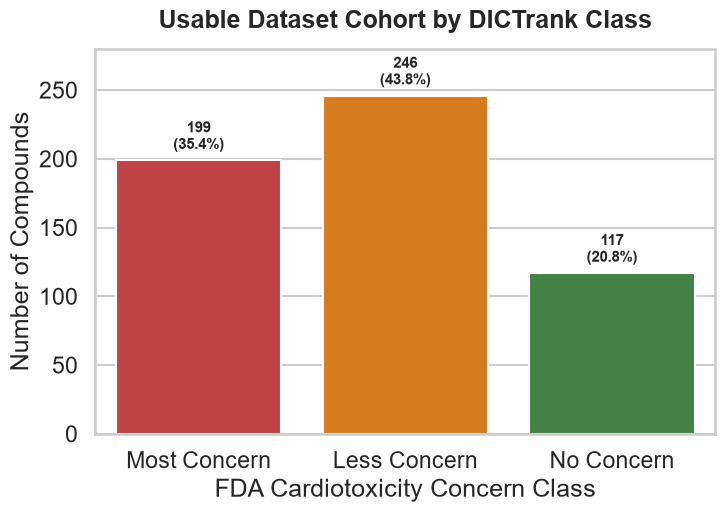

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 5))

classes = ["Most Concern", "Less Concern", "No Concern"]
counts = [199, 246, 117]
ax = sns.barplot(x=classes, y=counts, palette=["#d32f2f", "#f57c00", "#388e3c"], hue=classes, legend=False)

plt.title("Usable Dataset Cohort by DICTrank Class", pad=15, fontweight="bold")
plt.ylabel("Number of Compounds")
plt.xlabel("FDA Cardiotoxicity Concern Class")

for i, v in enumerate(counts):
    ax.text(i, v + 5, f"{v}\n({v/sum(counts):.1%})", ha="center", va="bottom", fontsize=11, fontweight="semibold")
plt.ylim(0, 280)
plt.show()

## 5. Visualization: Target Partition Sizes (70 / 15 / 15)
This chart compares the target partition sizes across the Drug-level split (stratified) and the Scaffold-level split.

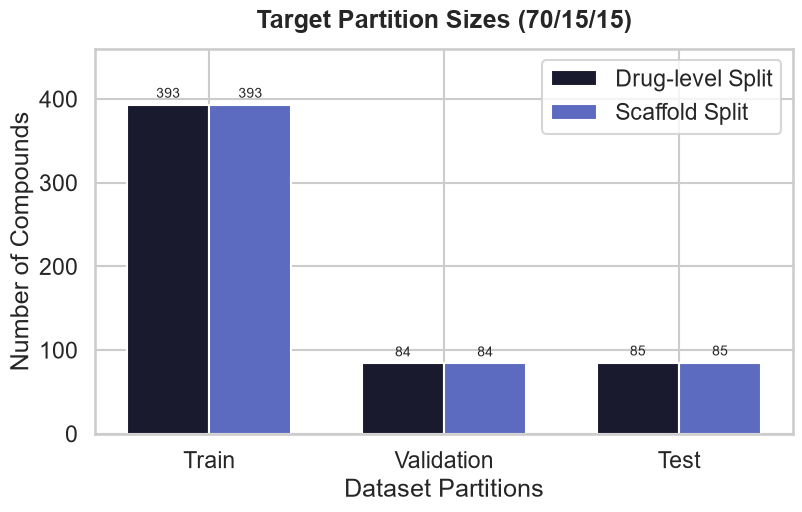

In [15]:
import numpy as np
plt.figure(figsize=(9, 5))

splits = ["Train", "Validation", "Test"]
drug_counts = [393, 84, 85]
scaf_counts = [393, 84, 85]

x = np.arange(len(splits))
width = 0.35

bar1 = plt.bar(x - width/2, drug_counts, width, label="Drug-level Split", color="#1a1a2e")
bar2 = plt.bar(x + width/2, scaf_counts, width, label="Scaffold Split", color="#5c6bc0")

plt.title("Target Partition Sizes (70/15/15)", pad=15, fontweight="bold")
plt.xticks(x, splits)
plt.ylabel("Number of Compounds")
plt.xlabel("Dataset Partitions")
plt.legend(frameon=True)

for bar in bar1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"{yval}", ha="center", va="bottom", fontsize=10)
for bar in bar2:
    yval = bar.get_height() 
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"{yval}", ha="center", va="bottom", fontsize=10)

plt.ylim(0, 460)
plt.show()